## 4.9. **분류 실습 - 캐글 산탄데르 고객 만족 예측**

#### ✅ 고객 만족 여부를 XGBoost 활용해 예측하기

- 데이터 전처리

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings

warnings.filterwarnings('ignore')

In [41]:
cust_df = pd.read_csv("./train_santander.csv", encoding='latin-1')
print('dataset shape:', cust_df.shape)
cust_df.head(3)

dataset shape: (76020, 371)


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.17,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.03,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.77,0


In [14]:
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB


➡️ 111개의 피처가 float형, 260개가 int형, NULL값 없음 

In [18]:
print(cust_df['TARGET'].value_counts())
unsatisfied_cnt = cust_df[cust_df['TARGET']==1].TARGET.count()
total_cnt = cust_df.TARGET.count()
print('unsatisfied 비율은 {0:.2f}'.format((unsatisfied_cnt / total_cnt)))

TARGET
0    73012
1     3008
Name: count, dtype: int64
unsatisfied 비율은 0.04


➡️ 대부분이 만족이며, 불만족인 고객은 4%에 불과함

In [25]:
cust_df.describe()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000
mean,75964.050723,-1523.199277,33.212865,86.208265,72.363067,119.529632,3.559130,6.472698,0.412946,0.567352,...,7.935824,1.365146,12.215580,8.784074,31.505324,1.858575,76.026165,56.614351,1.172358e+05,0.039569
std,43781.947379,39033.462364,12.956486,1614.757313,339.315831,546.266294,93.155749,153.737066,30.604864,36.513513,...,455.887218,113.959637,783.207399,538.439211,2013.125393,147.786584,4040.337842,2852.579397,1.826646e+05,0.194945
min,1.000000,-999999.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.163750e+03,0.000000
25%,38104.750000,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.787061e+04,0.000000
50%,76043.000000,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.064092e+05,0.000000
75%,113748.750000,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187563e+05,0.000000
max,151838.000000,238.000000,105.000000,210000.000000,12888.030000,21024.810000,8237.820000,11073.570000,6600.000000,6600.000000,...,50003.880000,20385.720000,138831.630000,91778.730000,438329.220000,24650.010000,681462.900000,397884.300000,2.203474e+07,1.000000


➡️ var3 칼럼의 경우, min 값이 -999999 (NaN이나 특정 예외 값의 변환)<br>
➡️ 편차가 너무 심하므로, -999999를 가장 많은 2로 변환 + ID 피처는 단순 식벌자에 불과하므로 드롭 

In [43]:
cust_df['var3'].replace(-999999, 2, inplace=True)
cust_df.drop('ID', axis=1, inplace=True)

# 피처 세트와 레이블 세트 분리. 레이블 칼럼은 DataFrame의 맨 마지막에 위치해 -1로 분리
X_features = cust_df.iloc[:,:-1]
y_labels = cust_df.iloc[:, -1]

print('피처 데이터 shape:{0}'.format(X_features.shape))

피처 데이터 shape:(76020, 369)


- 학습과 성능 평가를 위해 원본 데이터에서 학습 / 테스트 데이터 세트 분리
  (비대칭한 데이터 세트이므로 Target값 분포도 확인)

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels, test_size=0.2, random_state=0)

train_cnt = y_train.count()
test_cnt = y_test.count()
print('학습 세트 Shape:{0}, 테스트 세트 Shape:{1}'.format(X_train.shape, X_test.shape))

print('학습 세트 레이블 값 분포 비율')
print(y_train.value_counts()/train_cnt)
print('\n테스트 세트 레이블 값 분포 비율')
print(y_test.value_counts()/test_cnt)

학습 세트 Shape:(60816, 369), 테스트 세트 Shape:(15204, 369)
학습 세트 레이블 값 분포 비율
TARGET
0    0.960964
1    0.039036
Name: count, dtype: float64

테스트 세트 레이블 값 분포 비율
TARGET
0    0.9583
1    0.0417
Name: count, dtype: float64


➡️ 학습과 테스트 데이터 세트 모두 TARGET의 값의 분포가 원본 데이터와 유사하게 4%정도의 불만족 값으로 만들어짐 

In [53]:
# X_Train, y_train을 다시 학습과 검증 데이터 세트로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=0)

- XGBoost 모델 학습과 하이퍼 파라미터 튜닝
  <br>XGBoost의 학습 모델을 생성하고 예측결과를 ROC AUC로 평가하기 

In [59]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# n_estimators는 500으로, random state는 예제 수행 시마다 동일 예측 결과를 위해 설정
xgb_clf = XGBClassifier(n_estimators=500, learning_rate=0.05, random_state=156, early_stopping_rounds=100, eval_metric="auc")

# 성능 평가 지표를 auc로, 조기 중단 파라미터는 100으로 설정하고 학습 수행
xgb_clf.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr), (X_val, y_val)])

xgb_roc_score = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:,1])
print('ROU AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.83603	validation_1-auc:0.80978
[1]	validation_0-auc:0.83783	validation_1-auc:0.81126
[2]	validation_0-auc:0.83892	validation_1-auc:0.81192
[3]	validation_0-auc:0.84090	validation_1-auc:0.81349
[4]	validation_0-auc:0.84187	validation_1-auc:0.81356
[5]	validation_0-auc:0.84355	validation_1-auc:0.81422
[6]	validation_0-auc:0.84534	validation_1-auc:0.81550
[7]	validation_0-auc:0.84658	validation_1-auc:0.81623
[8]	validation_0-auc:0.84727	validation_1-auc:0.81669
[9]	validation_0-auc:0.84794	validation_1-auc:0.81668
[10]	validation_0-auc:0.84980	validation_1-auc:0.81828
[11]	validation_0-auc:0.85105	validation_1-auc:0.81965
[12]	validation_0-auc:0.85217	validation_1-auc:0.81999
[13]	validation_0-auc:0.85301	validation_1-auc:0.82049
[14]	validation_0-auc:0.85558	validation_1-auc:0.82210
[15]	validation_0-auc:0.85662	validation_1-auc:0.82288
[16]	validation_0-auc:0.85811	validation_1-auc:0.82380
[17]	validation_0-auc:0.85864	validation_1-auc:0.82365
[18]	validation_0-au

➡️ 테스트 데이터 세트로 예측시 약 0.8417

- HyperOpt를 이용해 베이지안 최적화 기반 하이퍼 파라미터 튜닝 수행 <br>- 검색 공간 설정

In [97]:
from hyperopt import hp

# max_depht는 5에서 15까지 1간격으로, min_child_weight는 1에서 6까지 1간격으로
# colsample_bytree는 0.5에서 0.95사이, learning_rate는 0.01에서 0.2사이 정규 분포된 값으로 검색
xgb_search_space = {'max_depth': hp.quniform('max_depth', 5, 15, 1),
                    'min_child_weight': hp.quniform('min_child_weight', 1, 6, 1),
                    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 0.95),
                    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2) }

- 목적 함수 

In [100]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

# fmin()에서 호출 시 search_space 값으로 XGBClassifier 교차 검증 학습 후 -1*roc_auc 평균 값을 반환
def objective_func(search_space):
    xgb_clf = XGBClassifier(n_estimators=100, max_depth=int(search_space['max_depth']),
                            min_child_weight=int(search_space['min_child_weight']),
                            colsample_bytree=search_space['colsample_bytree'],
                            learning_rate=search_space['learning_rate'],
                            early_stopping_rounds=30, eval_metric="auc" )

    # 3개 k-fold 방식으로 평가된 roc-auc 지표를 담는 list
    roc_auc_list = []

    # 3개 k-fold 방식 적용
    kf = KFold(n_splits=3)
    # X_train을 다시 학습과 검증용 데이터로 분리
    for tr_index, val_index in kf.split(X_train):
        # kf.split(X_train)으로 추출된 학습과 검증 index 값으로 학습과 검증 데이터 세트 분리
        X_tr, y_tr = X_train.iloc[tr_index], y_train.iloc[tr_index]
        X_val, y_val = X_train.iloc[val_index], y_train.iloc[val_index]

        # early stopping은 30회로 설정하고 추출된 학습과 검증 데이터로 XGBClassifier 학습 수행
        xgb_clf.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr),(X_val, y_val)])

        # 1로 예측한 확률값 추출 후 roc auc 계산하고 평균 roc auc 계산을 위해 list에 결괏값 담음
        score = roc_auc_score(y_val, xgb_clf.predict_proba(X_val)[:,1])
        roc_auc_list.append(score)

    # 3개 k-fold로 계산된 roc_auc 값의 평균값을 반환하되,
    # HyperOpt는 목적함수의 최솟값을 위한 입력값을 찾으므로 -1을 곱한 뒤 반환
    return -1*np.mean(roc_auc_list)

In [102]:
from hyperopt import fmin, tpe, Trials

trials = Trials()

# fmin()함수를 호출. max_evals 지정된 횟수만큼 반복 후 목적함수의 최솟값을 가지는 최적 입력값 추출
best = fmin(fn=objective_func,
            space=xgb_search_space,
            algo=tpe.suggest,
            max_evals=25, # 최대 반복 횟수를 지정
            trials=trials, rstate=np.random.default_rng(seed=30))

print('best:',best)

[0]	validation_0-auc:0.82881	validation_1-auc:0.80070                                                                  
[1]	validation_0-auc:0.83453	validation_1-auc:0.80438                                                                  
[2]	validation_0-auc:0.84292	validation_1-auc:0.81324                                                                  
[3]	validation_0-auc:0.84498	validation_1-auc:0.81897                                                                  
[4]	validation_0-auc:0.84983	validation_1-auc:0.82234                                                                  
[5]	validation_0-auc:0.84837	validation_1-auc:0.81951                                                                  
[6]	validation_0-auc:0.85080	validation_1-auc:0.82130                                                                  
[7]	validation_0-auc:0.85006	validation_1-auc:0.81946                                                                  
[8]	validation_0-auc:0.85450	validation_

➡️ 메모리 부족 이슈로 25회만 진행 
<br>➡️ colsample_bytree가 약 0.5609, lerning_rate가 약 0.1893, max_depth는 5.0, min_child_weight는 6.0이 도출됨 

In [106]:
# n_estimators를 500 증가 후 최적으로 찾은 하이퍼 파라미터를 기반으로 학습과 예측 수행
xgb_clf = XGBClassifier(n_estimators=500, learning_rate = round(best['learning_rate'], 5),
                        max_depth=int(best['max_depth']),
                        min_child_weight=int(best['min_child_weight']),
                        colsample_bytree=round(best['colsample_bytree'],5),
                        early_stopping_rounds=100,
                        eval_metric="auc"
                       )

# evaluation metric을 auc로, early stopping은 100으로 설정하고 학습 수행
xgb_clf.fit(X_tr, y_tr, eval_set=[(X_tr, y_tr),(X_val, y_val)])

xgb_roc_score = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:,1])
print('ROC_AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.74411	validation_1-auc:0.72004
[1]	validation_0-auc:0.82527	validation_1-auc:0.80201
[2]	validation_0-auc:0.82090	validation_1-auc:0.79748
[3]	validation_0-auc:0.82036	validation_1-auc:0.79573
[4]	validation_0-auc:0.83397	validation_1-auc:0.81171
[5]	validation_0-auc:0.83131	validation_1-auc:0.80901
[6]	validation_0-auc:0.84018	validation_1-auc:0.81760
[7]	validation_0-auc:0.83882	validation_1-auc:0.81519
[8]	validation_0-auc:0.84578	validation_1-auc:0.82029
[9]	validation_0-auc:0.85104	validation_1-auc:0.82729
[10]	validation_0-auc:0.85044	validation_1-auc:0.82596
[11]	validation_0-auc:0.85476	validation_1-auc:0.82909
[12]	validation_0-auc:0.85515	validation_1-auc:0.82834
[13]	validation_0-auc:0.85884	validation_1-auc:0.83082
[14]	validation_0-auc:0.86069	validation_1-auc:0.83222
[15]	validation_0-auc:0.86273	validation_1-auc:0.83268
[16]	validation_0-auc:0.86410	validation_1-auc:0.83246
[17]	validation_0-auc:0.86588	validation_1-auc:0.83328
[18]	validation_0-au

➡️ 이전의 0.8417에서 0.8453으로 개선됨 (순위 경쟁의 경우 유의미한 향상)

- 피처 중요도 그래프

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

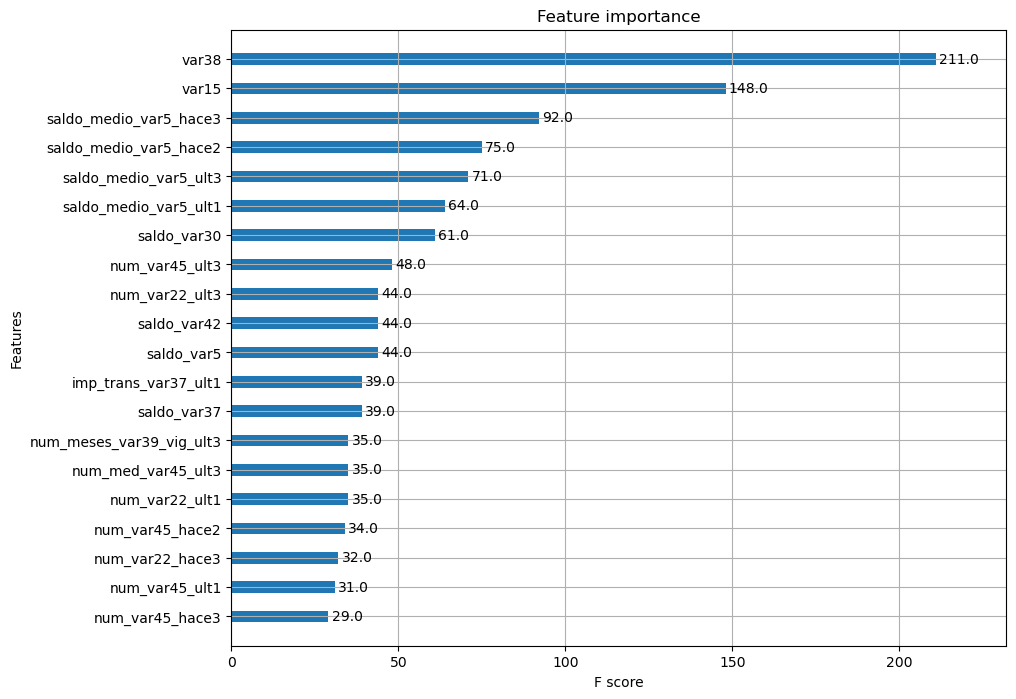

In [111]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(1,1,figsize=(10,8))
plot_importance(xgb_clf, ax=ax, max_num_features=20, height=0.4)

#### ✅ LightGBM 모델 학습과 하이퍼 파라미터 튜닝

- Light GBM으로 학습 수행

In [131]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

lgbm_clf = LGBMClassifier(n_estimators=500, early_stopping_rounds=100)

eval_set = [(X_tr, y_tr), (X_val, y_val)]
lgbm_clf.fit(X_tr, y_tr, eval_set=eval_set,eval_metric="auc")

lgbm_roc_score = roc_auc_score(y_test, lgbm_clf.predict_proba(X_test)[:, 1])
print('ROC AUC: {0:.4f}'.format(lgbm_roc_score)) 

[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[LightGBM] [Info] Number of positive: 1658, number of negative: 40913
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021023 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13308
[LightGBM] [Info] Number of data points in the train set: 42571, number of used features: 242
[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038947 -> initscore=-3.205836
[LightGBM] [Info] Start training from score -3.205836
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[42]	training's auc: 0.91059	training's binary_logloss: 0.112183	valid

➡️ XGBoost보다는 시간이 단축 

- 하이퍼 파라미터 튜닝 - 🕵️검색 공간 설정

In [145]:
lgbm_search_space = {'num_leaves':hp.quniform('num_leaves', 32, 64, 1),
                     'max_depth':hp.quniform('max_depth', 100, 160, 1),
                     'min_child_samples':hp.quniform('min_child_samples', 60, 100, 1),
                     'subsample':hp.uniform('subsample', 0.7, 1),
                     'learning_rate':hp.uniform('learning_rate', 0.01, 0.2)
                    }

- 목적 함수 생성

In [153]:
def objective_func(search_space):
    lgbm_clf = LGBMClassifier(n_estimators=100,
                              num_leaves = int(search_space['num_leaves']),
                              max_depth = int(search_space['max_depth']),
                              min_child_samples = int(search_space['min_child_samples']),
                              subsample = search_space['subsample'],
                              learning_rate = search_space['learning_rate'],
                              early_stopping_rounds=30 )
    # 3개 k-fold 방식으로 평가된 roc_auc 지표를 담는 list
    roc_auc_list = []

    # 3개 k-fold 방식 적용
    kf = KFold(n_splits=3)
    # X_train을 다시 학습과 검증용 데이터로 분리
    for tr_index, val_index in kf.split(X_train):
        # kf.split(X_train)으로 추출된 학습과 검증 데이터 세트 분리
        X_tr, y_tr = X_train.iloc[tr_index], y_train.iloc[tr_index]
        X_val, y_val = X_train.iloc[val_index], y_train.iloc[val_index]

        # early stopping은 30회로 설정하고 추출된 학습과 검증 데이터로 XGBClassifier 학습 수행
        lgbm_clf.fit(X_tr, y_tr, eval_metric="auc", eval_set=[(X_tr, y_tr), (X_val, y_val)])

        # 1로 예측한 확률값 추출 후 roc auc계산하고 평균 계산을 위해 list에 담기
        score = roc_auc_score(y_val, lgbm_clf.predict_proba(X_val)[:,1])
        roc_auc_list.append(score)

    # 3개 k-fold로 계산된 roc auc 값의 평균을 반환하되, HyperOpt는 최솟값을 위한 입력값을 찾으므로 -1 곱해서 반환 
    return -1*np.mean(roc_auc_list)

- `fmin()` 호출하여 최적 하이퍼 파라미터 도출

In [156]:
from hyperopt import fmin, tpe, Trials

trials = Trials()

# fmin() 함수를 호출. max_evals 지정된 횟수만큼 반복 후 목적함수의 최솟값을 가지는 최적 입력값 추출
best = fmin(fn=objective_func, space=lgbm_search_space, algo=tpe.suggest, max_evals=25, trials=trials,
            rstate = np.random.default_rng(seed=30))

print('best:', best)

[LightGBM] [Warning] early_stopping_round is set=30, early_stopping_rounds=30 will be ignored. Current value: early_stopping_round=30
[LightGBM] [Info] Number of positive: 1579, number of negative: 38965                                                  
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016864 seconds.                
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12827                                                                                     
[LightGBM] [Info] Number of data points in the train set: 40544, number of used features: 192                          
[LightGBM] [Warning] early_stopping_round is set=30, early_stopping_rounds=30 will be ignored. Current value: early_stopping_round=30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038945 -> initscore=-3.205872                                        
[LightGBM]

In [158]:
lgbm_clf = LGBMClassifier(n_estimators = 500, num_leaves=int(best['num_leaves']),
                          max_depth = int(best['max_depth']),
                          min_child_samples = int(best['min_child_samples']),
                          subsample = round(best['subsample'], 5),
                          learning_rate = round(best['learning_rate'], 5),
                          early_stopping_rounds=100
                         )

# evaluation metric을 auc로, early stopping은 100으로 설정하고 학습 수행
lgbm_clf.fit(X_tr, y_tr, eval_metric="auc", eval_set=[(X_tr, y_tr),(X_val, y_val)])

lgbm_roc_score = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:,1])
print('ROC AUC : {0:.4f}'.format(lgbm_roc_score))

[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[LightGBM] [Info] Number of positive: 1658, number of negative: 40913
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.047009 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12992
[LightGBM] [Info] Number of data points in the train set: 42571, number of used features: 200
[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038947 -> initscore=-3.205836
[LightGBM] [Info] Start training from score -3.205836
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[139]	training's auc: 0.904088	training's binary_logloss: 0.115808	val

➡️ 상대적으로 빠른 시간에 하이퍼 파라미터 튜닝 수행 가능 ( ROC-AUC 값은 0.8453 )

## **4.10. 분류 실습 - 캐글 신용카드 사기 검출**

### 📄 Outlier
전체 데이터의 패턴에서 벗어난 이상 값을 가진 데이터 <br>
⇒  머신러닝 모델의 성능이 영향을 받는 경우가 발생하기 쉬움 <br>
⇒ 이상치를 찾는 방법 중 하나가 **IQR**<br>


### 📄 IQR (Inter Quantile Range)
사분위 값(Quantile)의 편차를 이용하는 기법, 흔히 박스 플롯(Box Plot)방식으로 시각화 가능

- **사분위**<br>
    : 전체 데이터를 값이 높은 순으로 정렬하고 이를 25% 씩 구간으로 분할하는 것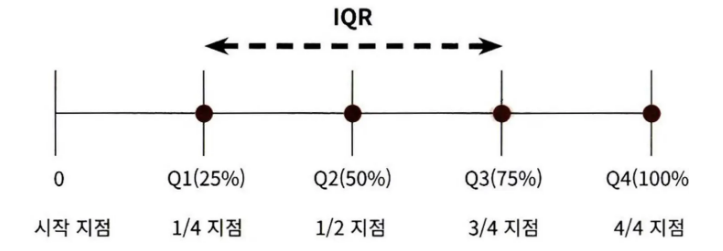<br>⇒ 이들중 25% ~ 75% (Q1 ~ Q3) 구간을 IQR이라고 함

- **IQR 이용 방식**
    <br>보통 IQR에 1.5를 곱해서 생성된 범위 밖 데이터를 이상치로 간주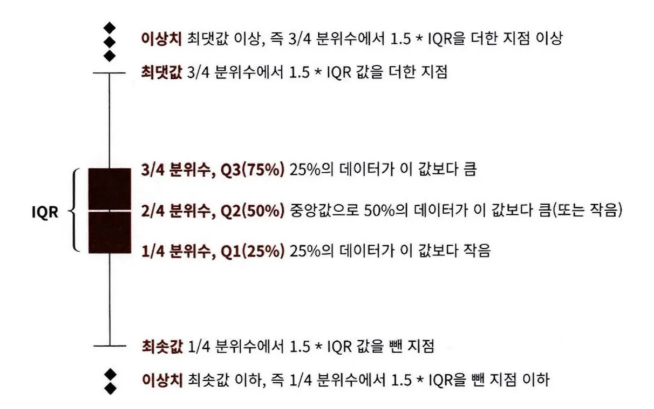

#### ✅ 데이터 일차 가공 및 모델 학습/예측/평가

- 데이터 세트 로딩

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

card_df = pd.read_csv('./creditcard.csv')
card_df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


➡️ `Time` 피처의 경우 데이터 생성 관련 작업용 속성으로서 큰 의미가 없기에 제거<br>
➡️ `Amount` 피처의 경우 신용카드 트랜잭션 금액을 의미하는 레이블 (0인경우 정상, 1인경우 사기)

In [15]:
card_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

➡️ 전체 레코드에서 결측치(Missing Value)는 없음 
<br>
➡️ Class레이블 (int)를 제외한 모든 피처들은 float형 

- 데이터 가공용 함수 생성

In [19]:
from sklearn.model_selection import train_test_split

# 인자로 입력받은 DataFrame을 복사한 뒤 Time 칼럼만 삭제하고 복사된 DataFrame 반환
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    df_copy.drop('Time', axis=1, inplace=True)
    return df_copy

In [29]:
# 사전 데이터 가공 후 학습과 테스트 데이터 세트를 반환하는 함수
def get_train_test_dataset(df=None):
    # 인자로 입력된 DataFrame의 사전 데이터 가공이 완료된 복사 DataFrame 반환
    df_copy = get_preprocessed_df(df)
    # DataFrame의 맨 마지막 칼럼이 레이블, 나머지는 피처들
    X_features = df_copy.iloc[:, :-1]
    y_target = df_copy.iloc[:,-1]
    # train_test_split()으로 학습과 테스트 데이터 분할. stratify = y_target으로 Stratified기반 분할 
    X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.3, random_state=0, stratify=y_target)
    # 학습과 테스트 데이터 세트 반환
    return X_train, X_test, y_train, y_test

In [33]:
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

- 생성한 학습 데이터 세트와 테스트 데이터 세트 레이블 값 비율 확인 

In [39]:
print('학습 데이터 레이블 값 비율')
print(y_train.value_counts()/y_train.shape[0]*100)
print('테스트 데이터 레이블 값 비율')
print(y_test.value_counts()/y_test.shape[0]*100)

학습 데이터 레이블 값 비율
Class
0    99.827451
1     0.172549
Name: count, dtype: float64
테스트 데이터 레이블 값 비율
Class
0    99.826785
1     0.173215
Name: count, dtype: float64


➡️ 두 데이터 세트의 레이블 값 비율의 비슷하게 잘 분할 됨

- 로지스틱 회귀 기반 예측 수행

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import f1_score, confusion_matrix, precision_recall_curve, roc_curve

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도 : {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC: {4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [51]:
from sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(max_iter=1000)
lr_clf.fit(X_train, y_train)
lr_pred = lr_clf.predict(X_test)
lr_pred_proba = lr_clf.predict_proba(X_test)[:,1]

# 3장에서 사용한 get_clf_eval 함수를 이용해 평가 수행 
get_clf_eval(y_test, lr_pred, lr_pred_proba)

오차 행렬
[[85280    15]
 [   56    92]]
정확도: 0.9992, 정밀도 : 0.8598, 재현율: 0.6216,    F1: 0.7216, AUC: 0.9725


- LightGBM을 이용한 모델으로 예측 - 함수 생성

In [61]:
# 인자로 사이킷런의 Estimator 객체와 학습/테스트 데이터 세트를 입력받아서 학습/예측/평가 수행
def get_model_train_eval(model, ftr_train=None, ftr_test=None, tgt_train=None, tgt_test=None):
    model.fit(ftr_train, tgt_train)
    pred = model.predict(ftr_test)
    pred_proba = model.predict_proba(ftr_test)[:,1]
    get_clf_eval(tgt_test, pred, pred_proba)

🚨 본 데이터 세트는 극도로 불균형한 레이블 값 분포를 가지고 있으므로 LGBMClssifier객체 생성시 `boost_from_average=False`로 파라미터를 설정해야함 

In [66]:
from lightgbm import LGBMClassifier

lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

[LightGBM] [Info] Number of positive: 344, number of negative: 199020
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014743 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7395
[LightGBM] [Info] Number of data points in the train set: 199364, number of used features: 29
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

➡️ 로지스틱 회귀<br>
  : 정확도: 0.9992, 정밀도 : 0.8598, 재현율: 0.6216,    F1: 0.7216, AUC: 0.9725<br>
➡️ 로지스틱 회귀보다 높은 수치를 나타냄 

#### ✅ 데이터 분포도 변환 후 모델 학습/예측/평가

- creditcard.csv의 중요 피처 값의 분포도 살펴보기

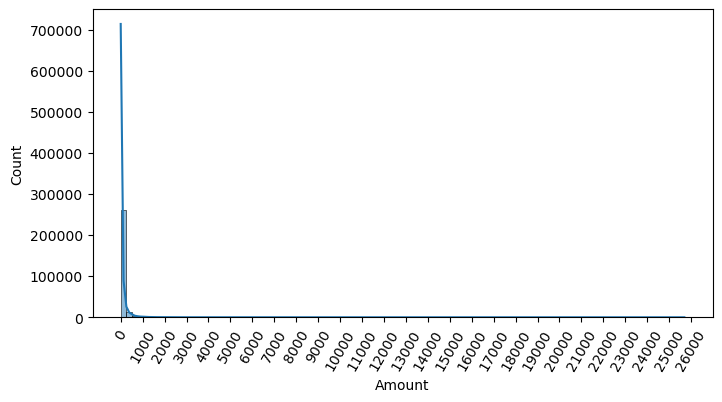

In [76]:
import seaborn as sns

plt.figure(figsize=(8,4))
plt.xticks(range(0, 30000, 1000), rotation=60)
sns.histplot(card_df['Amount'], bins=100, kde=True)
plt.show()

➡️ `Amount` 카드 사용 금액이 1000불 이하인 데이터가 대부분, 꼬리가 진 형태의 분포 곡선을 가지고 있음 

- `Amount`를 정규분포 형태로 변환 

In [82]:
from sklearn.preprocessing import StandardScaler
# 사이킷런의 StandardScaler를 이용해 정규 분포 형태로 Amount 피처값 변환하는 로직으로 수정
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    scaler = StandardScaler()
    amount_n = scaler.fit_transform(df_copy['Amount'].values.reshape(-1,1))
    # 변환된 Amount를 Amount_Scaled로 피처명 변경 후 DataFrame맨 앞 칼럼으로 입력
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    # 기존 Time, Amount 피처 삭제
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    return df_copy

- 로지스틱 회귀와 LightGBM 모델을 각각 학습/예측/평가 

In [88]:
# Amount를 정규 분포 형태로 변환 후 로지스틱 회귀 및 LightGBM 수행
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

print('### 로지스틱 회귀 예측 성능 ###')
lr_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

print('### LightGBM 예측 성능 ###')
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False, verbose=-1)
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

### 로지스틱 회귀 예측 성능 ###
오차 행렬
[[85281    14]
 [   55    93]]
정확도: 0.9992, 정밀도 : 0.8692, 재현율: 0.6284,    F1: 0.7294, AUC: 0.9706
### LightGBM 예측 성능 ###
오차 행렬
[[85290     5]
 [   37   111]]
정확도: 0.9995, 정밀도 : 0.9569, 재현율: 0.7500,    F1: 0.8409, AUC: 0.9779


➡️ 로지스틱 회귀의 경우, 정밀도와 재현율이 조금 저하<br>
➡️ LightGBM의 경우 정밀도와 재현율이 저하되었지만 큰 성능상 변화X

- `Amount` 로그변환 후 예측 성능 확인

로그 변환은 원래 값을 log값으로 변환해 큰 값을 상대적으로 작은 값으로 변환해 줌 

In [95]:
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    # 넘파이의 log1p()를 이용해 Amount를 로그 변환
    amount_n = np.log1p(df_copy['Amount'])
    df_copy.insert(0,'Amount_Scaled', amount_n)
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    return df_copy

In [97]:
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

print('### 로지스틱 회귀 예측 성능 ###')
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

print('### LightGBM 예측 성능 ###')
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

### 로지스틱 회귀 예측 성능 ###
오차 행렬
[[85282    13]
 [   59    89]]
정확도: 0.9992, 정밀도 : 0.8725, 재현율: 0.6014,    F1: 0.7120, AUC: 0.9734
### LightGBM 예측 성능 ###
오차 행렬
[[85290     5]
 [   35   113]]
정확도: 0.9995, 정밀도 : 0.9576, 재현율: 0.7635,    F1: 0.8496, AUC: 0.9796


➡️ 로지스틱 회귀의 경우 정밀도는 향상되었으나, 재현율은 저하<br>
➡️ LightGBM의 경우 재현율을 향상<br>
➡️ 레이블이 극도로 불균일한 데이터 세트에서 로지스틱 회귀는 데이터 변환 시 약간은 불안정한 성능 결과를 보여줌 

#### ✅ 이상치 데이터 제거 후 모델 학습/예측/평가

- 피처별 레이블과의 상관도 시각화

<Axes: >

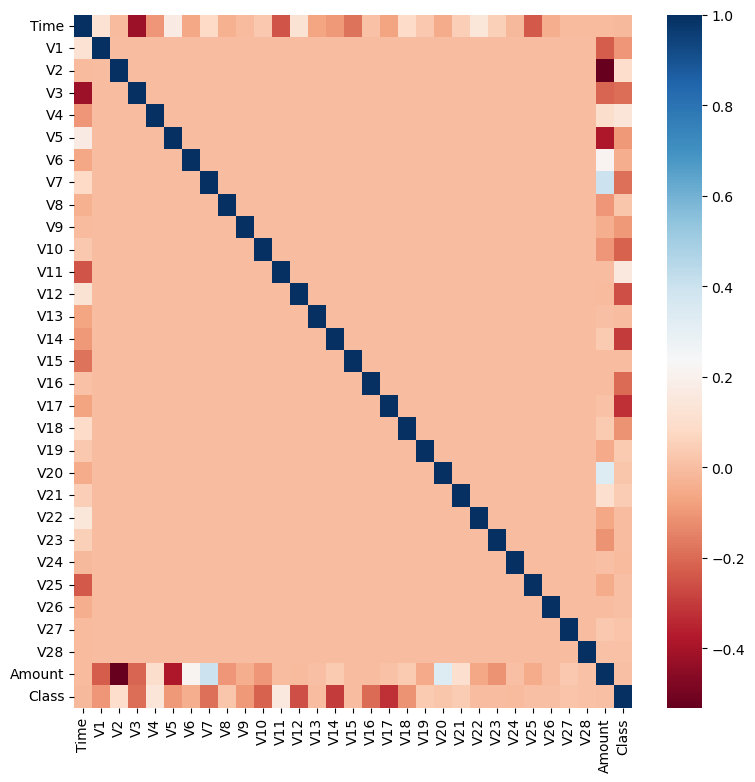

In [103]:
import seaborn as sns

plt.figure(figsize=(9,9))
corr = card_df.corr()

sns.heatmap(corr, cmap='RdBu')

➡️ `V14`,`V17`이 `Class`와 음의 상관관계가 가장 높음 

- `V14`에 대한 이상치 제거 함수 생성

In [121]:
import numpy as np

def get_outlier(df=None, column=None, weight=1.5):
    # fraud에 해당하는 column 데이터만 추출, 1/4분위와 3/4분위 지점을 np.percentile로 구함
    fraud = df[df['Class']==1][column]
    quantile_25 = np.percentile(fraud.values, 25)
    quantile_75 = np.percentile(fraud.values, 75)
    # IQR을 구하고, IQR에 1.5를 곱해 최댓값과 최솟값 지점 구함 
    iqr = quantile_75-quantile_25
    iqr_weight = iqr*weight
    lowest_val = quantile_25 - iqr_weight
    highest_val = quantile_75 + iqr_weight
    # 최댓값보다 크거나, 최솟값보다 작은 값을 이상치 데이터로 설정하고 DataFrame index 반환
    outlier_index = fraud[(fraud<lowest_val) | (fraud>highest_val)].index
    return outlier_index

In [125]:
outlier_index = get_outlier(df=card_df, column='V14', weight=1.5)
print('이상치 데이터 인덱스:', outlier_index)

이상치 데이터 인덱스: Index([8296, 8615, 9035, 9252], dtype='int64')


➡️ 총 4개의 데이터 인덱스가 이상치로 추출 

- 이상치 삭제 후 모델 적용

In [129]:
# get_processed_df() 를 로그 변환 후 V14 피처의 이상치 데이터를 삭제하는 로직으로 변경
def get_preprocessed_df(df=None):
    df_copy = df.copy()
    amount_n = np.log1p(df_copy['Amount'])
    df_copy.insert(0,'Amount_Scaled', amount_n)
    df_copy.drop(['Time','Amount'], axis=1, inplace=True)
    # 이상치 데이터 삭제 로직 추가
    outlier_index = get_outlier(df=card_df, column='V14', weight=1.5)
    df_copy.drop(outlier_index, axis=0, inplace=True)
    return df_copy

In [131]:
X_train, X_test, y_train, y_test = get_train_test_dataset(card_df)

print('### 로지스틱 회귀 예측 성능 ###')
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

print('### LightGBM 예측 성능 ###')
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

### 로지스틱 회귀 예측 성능 ###
오차 행렬
[[85280    15]
 [   48    98]]
정확도: 0.9993, 정밀도 : 0.8673, 재현율: 0.6712,    F1: 0.7568, AUC: 0.9725
### LightGBM 예측 성능 ###
오차 행렬
[[85290     5]
 [   25   121]]
정확도: 0.9996, 정밀도 : 0.9603, 재현율: 0.8288,    F1: 0.8897, AUC: 0.9780


➡️ 로지스틱 회귀와 LightGBM모두 예측 성능이 크게 향상 <br>
➡️ 로지스틱 회귀의 경우 재현율이 60.14% -> 67.12%로 향상 <br>
➡️ LightGBM의 경우도 76.35% -> 82.88%로 크게 증가함

#### ✅ SMOTE 오버 샘플링 적용 후 모델 학습/예측/평가

- SMOTE를 적용할 때는 반드시 학습 데이터 세트만 오버 샘플링을 해야함
- 검증 데이터나 테스트 데이터를 오버샘플링할 경우, 올바른 검증/테스트가 될 수 없음



- 데이터 증식 후 증식 전 데이터와 비교해보기

In [149]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)
print('SMOTE 적용 전 학습용 피처/레이블 세트:', X_train.shape, y_train.shape)
print('SMOTE 적용 후 학습용 피처/레이블 세트:', X_train_over.shape, y_train_over.shape)
print('SMOTE 적용 후 레이블 값 분포:\n', pd.Series(y_train_over).value_counts())

SMOTE 적용 전 학습용 피처/레이블 세트: (199362, 29) (199362,)
SMOTE 적용 후 학습용 피처/레이블 세트: (398040, 29) (398040,)
SMOTE 적용 후 레이블 값 분포:
 Class
0    199020
1    199020
Name: count, dtype: int64


➡️ SMOTE 적용 후 2배에 가깝게 데이터가 증식됨 
<br>➡️ 0과 1의 분포가 동일하게 생성됨 

- 증식된 학습 데이터 세트를 기반으로 로지스틱 회귀 예측 수행

In [155]:
lr_clf = LogisticRegression(max_iter=1000)
# ftr_train과 tgt인자값이 SMOTE 증식된 X_train_over와 y_trian_over로 변경됨에 유의
get_model_train_eval(lr_clf, ftr_train=X_train_over, ftr_test=X_test, tgt_train=y_train_over, tgt_test=y_test)

오차 행렬
[[82933  2362]
 [   11   135]]
정확도: 0.9722, 정밀도 : 0.0541, 재현율: 0.9247,    F1: 0.1022, AUC: 0.9736


➡️ 로지스틱의 경우 SMOTE로 오버 샘플링도니 데이터로 학습할 경우 재현율이 92.47%로 크게 증가 / 반대로 정밀도가 5.4%로 급격하게 저하
<br>➡️ 오버 샘플링으로 실제 원본보다 너무 많은 `Class=1`데이터를 학습하면서 실제 test 중 예측을 지나치게 `1`로 적용해 정밀도 저하 유발 

- 분류 결정 임계값에 따른 정밀도-재현율 곡선 시각화 

In [162]:
import matplotlib.ticker as ticker

thresholds = [0.4, 0.45, 0.50, 0.55, 0.60]

def precision_recall_curve_plot(y_test, pred_proba_c1):
    # threshold ndarray와 이 threshold에 따른 정밀도, 재현율 ndarray 추출.
    precisions, recalls, thresholds = precision_recall_curve(y_test, pred_proba_c1)

    # X축으로 threshold값으로, Y축은 정밀도, 재현율 값으로 각각 Plot 수행. 정밀도는 점선으로 표시
    plt.figure(figsize=(8,6))
    threshold_boundary = thresholds.shape[0]
    plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
    plt.plot(thresholds, recalls[0:threshold_boundary], label='recall')

    # threshold 값 X 축의 Scale을 0.1 단위로 변경
    start, end = plt.xlim()
    plt.xticks(np.round(np.arange(start, end, 0.1),2))

    # X축, Y축 label과 legend, 그리고 grid 설정
    plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
    plt.legend(); plt.grid()
    plt.show()

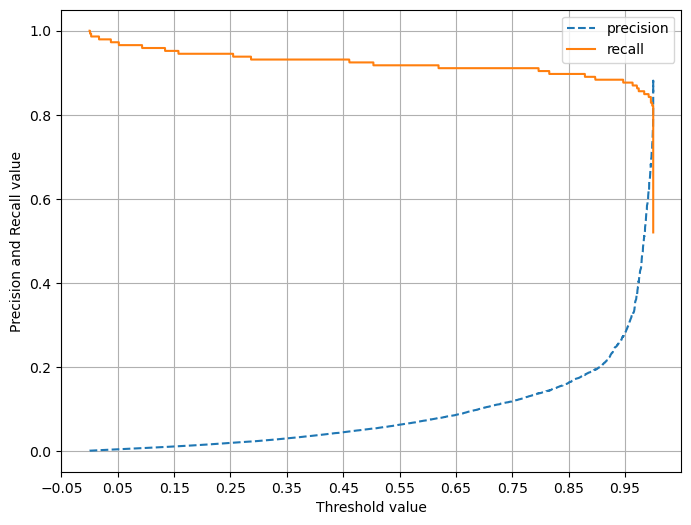

In [164]:
precision_recall_curve_plot(y_test, lr_clf.predict_proba(X_test)[:,1])

➡️ 0.99이하에서는 재현율이 매우 좋고 정밀도가 낮다가, 0.99 이상에서는 반대로 재현율이 떨어지고 정밀도가 높아짐 <br>
➡️ 분류 결정 임계값을 조정하더라도 임계값의 민감도가 너무 심하다 

- LightGBM모델으로 오버샘프링 데이터 학습/예측/평가

In [170]:
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train_over, ftr_test=X_test, tgt_train=y_train_over, tgt_test=y_test)

오차 행렬
[[85283    12]
 [   22   124]]
정확도: 0.9996, 정밀도 : 0.9118, 재현율: 0.8493,    F1: 0.8794, AUC: 0.9814


➡️ 재현율이 이상치만 제거한 경우보다 높아짐 / 그러나 정밀도는 낮아짐 <br>
➡️ SMOTE를 적용하면 재현율을 높아지나, 정밀도는 낮아지는 것이 일반적 <br>
➡️ 정밀도 지표보다 재현율을 높이는 것이 목표인 경우 적용하면 좋음 

-----

## Decision Tree And Random Forest Classifier Models 

- 필요 패키지 로드

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

### ✅ Data Review

In [4]:
data = pd.read_csv("./drug200.csv")
data

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [18]:
# 데이터 정보
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [22]:
# 데이터 값
data.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [39]:
# 데이터 correlation
data.select_dtypes(include=[np.number]).corr()

,Age,Na_to_K
Age,1.000000,-0.063119
Na_to_K,-0.063119,1.000000


- 시각화하기 

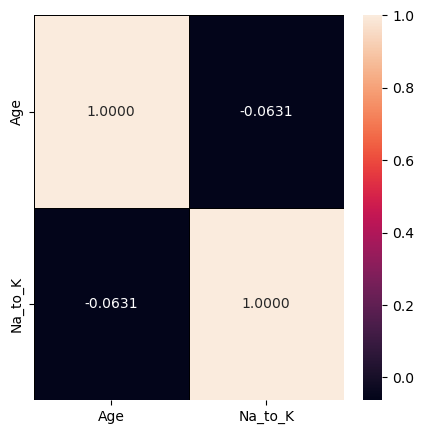

In [43]:
f, ax = plt.subplots(figsize = (5,5))
sns.heatmap(data.select_dtypes(include=[np.number]).corr(), annot = True, linewidths=0.5, linecolor = "black", fmt = ".4f", ax=ax)
plt.show()

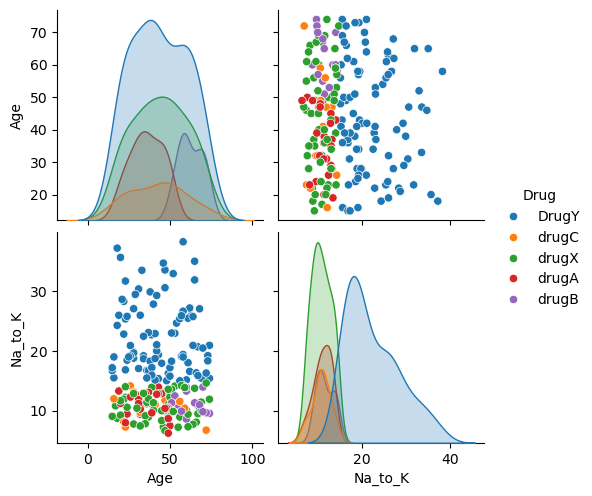

In [46]:
sns.pairplot(data, hue="Drug")

- 칼럼 별 데이터 확인

In [50]:
# data in the age column
data["Age"].value_counts(dropna=False)

Age
47    8
23    7
28    7
49    7
39    6
32    6
50    5
37    5
58    5
60    5
22    5
34    4
72    4
51    4
42    4
26    4
24    4
74    4
67    4
68    4
61    4
56    4
20    4
36    4
45    4
41    4
31    4
43    4
65    4
57    4
53    3
40    3
70    3
59    3
16    3
38    3
15    3
69    3
35    3
18    3
64    3
52    2
55    2
62    2
19    2
29    2
66    2
73    2
46    2
48    2
54    1
17    1
33    1
63    1
30    1
21    1
25    1
Name: count, dtype: int64

In [54]:
# data in the Sex column
data["Sex"].value_counts()

Sex
M    104
F     96
Name: count, dtype: int64

In [58]:
# data in the BP (Blood Pressure Levels) column
data["BP"].value_counts()

BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64

In [64]:
# data in the Cholesterol column
data["Cholesterol"].value_counts()

Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64

In [68]:
# data in the drug column
data["Drug"].value_counts()

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

### ✅ Data Visualization

In [25]:
# age 데이터 시각화
dataAge = data["Age"].value_counts(dropna=False)
npar_dataAge = np.array(dataAge)
x = list(npar_dataAge)
y = data.Age.value_counts().index

DataAge = {"Age":y, "Number":x}
DataAge = pd.DataFrame(DataAge)

fig = px.bar(DataAge, x="Age", y="Number")
fig.show("iframe")

In [27]:
# visualize the number of sex in the dataset
colors = ['gold', 'mediumturquoise']

fig = go.Figure(data=[go.Pie(labels=['M','F'], values=[104,96])])

fig.update_traces(hoverinfo = 'label + percent', textinfo='value', textfont_size=20, 
                  marker = dict(colors = colors, line=dict(color='#000000', width=2)))

fig.show("iframe")

In [31]:
# the number of BP
fig = px.bar(x = ["HIGH", "LOW", "NORMAL"], y=[77,64,59])

fig.show("iframe")

In [35]:
# the number of Cholesterol
fig = px.histogram(x = ["HIGH", "NORMAL"], y=[103,97])
fig.show("iframe")

In [39]:
# number of Drug
fig = go.Figure(data = [go.Pie(labels=["DrugY", "DrugX", "DrugA", "DrugC", "DrugB"], values=[91,54,23,16,16])])

fig.update_traces(hoverinfo = 'label + percent', textinfo = 'value', textfont_size = 20,
                  marker = dict(colors = px.colors.sequential.RdBu, line = dict(color = '#000000', width=2)))

fig.show("iframe")

In [43]:
# Na_To_K (Na to Potasssium Ration)와 age의 관계
fig = px.scatter(data, x="Na_to_K", y="Age", color="Drug", size='Age', hover_data=['Na_to_K'])
fig.show("iframe")

### ✅ Classification Models

- 데이터 준비

In [5]:
dataclass = pd.read_csv("./drug200.csv")
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [53]:
dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


➡️ object 타입 변환 필요

In [145]:
# F=1, M=0으로 인코딩
dataclass.Sex = [1 if i=='F' else 0 for i in dataclass.Sex]
dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,HIGH,HIGH,25.355,DrugY
1,47,0,LOW,HIGH,13.093,drugC
2,47,0,LOW,HIGH,10.114,drugC
3,28,1,NORMAL,HIGH,7.798,drugX
4,61,1,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,LOW,HIGH,11.567,drugC
196,16,0,LOW,HIGH,12.006,drugC
197,52,0,NORMAL,HIGH,9.894,drugX
198,23,0,NORMAL,NORMAL,14.020,drugX


In [147]:
# BP 
# Low = 2 / NORMAL = 1 / HIGH = 0

import warnings
warnings.filterwarnings('ignore')

for i in range(0, len(dataclass.BP)):
    if dataclass.BP[i] == "LOW":
        dataclass.BP[i] = 2
    elif dataclass.BP[i] == "NORMAL":
        dataclass.BP[i] = 1
    else:
        dataclass.BP[i] = 0

dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,HIGH,25.355,DrugY
1,47,0,2,HIGH,13.093,drugC
2,47,0,2,HIGH,10.114,drugC
3,28,1,1,HIGH,7.798,drugX
4,61,1,2,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,2,HIGH,11.567,drugC
196,16,0,2,HIGH,12.006,drugC
197,52,0,1,HIGH,9.894,drugX
198,23,0,1,NORMAL,14.020,drugX


In [149]:
# Cholesterol
# HIGH=1 / NORMAL=0
dataclass.Cholesterol = [1 if i == 'HIGH' else 0 for i in dataclass.Cholesterol]

dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,1,25.355,DrugY
1,47,0,2,1,13.093,drugC
2,47,0,2,1,10.114,drugC
3,28,1,1,1,7.798,drugX
4,61,1,2,1,18.043,DrugY
...,...,...,...,...,...,...
195,56,1,2,1,11.567,drugC
196,16,0,2,1,12.006,drugC
197,52,0,1,1,9.894,drugX
198,23,0,1,0,14.020,drugX


In [151]:
# Drug type
# DrugY=4 / DrugX=3 / DrugA=2 / DrugC=1 / Drug=0

import warnings
warnings.filterwarnings('ignore')

for i in range(0, len(dataclass)):
    if dataclass.Drug[i] == "DrugY":
        dataclass.Drug[i] = 4
    elif dataclass.Drug[i] == "drugX":
        dataclass.Drug[i] = 3
    elif dataclass.Drug[i] == "drugA":
        dataclass.Drug[i] = 2
    elif dataclass.Drug[i] == "drugC":
        dataclass.Drug[i] = 1
    else:
        dataclass.Drug[i] = 0 

dataclass

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,1,0,1,25.355,4
1,47,0,2,1,13.093,1
2,47,0,2,1,10.114,1
3,28,1,1,1,7.798,3
4,61,1,2,1,18.043,4
...,...,...,...,...,...,...
195,56,1,2,1,11.567,1
196,16,0,2,1,12.006,1
197,52,0,1,1,9.894,3
198,23,0,1,0,14.020,3


In [153]:
dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(3), object(2)
memory usage: 9.5+ KB


➡️ BP, Drug를 int로 바꿔야해

In [155]:
data_types_dict = {'BP':int, "Drug":int}

dataclass = dataclass.astype(data_types_dict)

dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    int32  
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    int32  
dtypes: float64(1), int32(2), int64(3)
memory usage: 7.9 KB


- 데이터 분리 

In [157]:
x_data = dataclass.drop(["Drug"], axis=1)
y_data = dataclass.Drug.values

In [159]:
x_data

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,1,0,1,25.355
1,47,0,2,1,13.093
2,47,0,2,1,10.114
3,28,1,1,1,7.798
4,61,1,2,1,18.043
...,...,...,...,...,...
195,56,1,2,1,11.567
196,16,0,2,1,12.006
197,52,0,1,1,9.894
198,23,0,1,0,14.020


In [161]:
y_data

array([4, 1, 1, 3, 4, 3, 4, 1, 4, 4, 1, 4, 4, 4, 3, 4, 3, 2, 1, 4, 4, 4,
       4, 4, 4, 4, 4, 3, 4, 4, 3, 0, 3, 4, 3, 3, 2, 3, 3, 3, 4, 0, 4, 3,
       3, 3, 2, 1, 4, 4, 4, 3, 4, 4, 0, 1, 0, 4, 3, 4, 4, 2, 4, 3, 0, 4,
       2, 3, 4, 4, 0, 4, 3, 4, 4, 4, 2, 4, 2, 3, 0, 3, 1, 2, 1, 0, 3, 4,
       4, 4, 4, 4, 4, 4, 4, 3, 4, 4, 4, 4, 2, 2, 1, 3, 4, 3, 3, 4, 0, 4,
       2, 3, 3, 3, 3, 4, 3, 3, 2, 4, 4, 4, 4, 4, 0, 4, 4, 3, 4, 3, 4, 4,
       3, 4, 4, 3, 0, 2, 0, 3, 2, 4, 0, 4, 2, 3, 3, 2, 3, 1, 2, 0, 3, 3,
       4, 1, 2, 4, 1, 3, 3, 0, 3, 4, 4, 4, 4, 3, 4, 2, 3, 3, 4, 4, 2, 4,
       2, 4, 4, 4, 4, 3, 3, 4, 4, 4, 0, 2, 4, 4, 4, 2, 4, 1, 4, 1, 1, 3,
       3, 3])

In [163]:
# Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.3, random_state=1)

#### ✅ dicision tree classifier

데이터에 있는 규칙을 학습을 통해 자동으로 찾아내 트리(Tree) 기반의 분류 규칙을 생성

In [165]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

dtc = DecisionTreeClassifier()

# Fit the model
dtc.fit(x_train, y_train)

# prediction
predict = dtc.predict(x_test)

print('The accuracy of the Decision Tree is', metrics.accuracy_score(y_test, predict))

The accuracy of the Decision Tree is 0.9666666666666667


- 지니계수 사용한 DTC

In [167]:
DTC_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)

# Fitting
DTC_gini.fit(x_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [169]:
y_pred_gini = DTC_gini.predict(x_test)

In [171]:
from sklearn.metrics import accuracy_score

print('Model accuracy score with criterion gini index: {0:0.4f}'.format(accuracy_score(y_test, y_pred_gini)))

Model accuracy score with criterion gini index: 0.9000


In [173]:
y_pred_train_gini = DTC_gini.predict(x_train)

y_pred_train_gini

array([3, 3, 2, 4, 2, 3, 3, 3, 4, 2, 0, 3, 4, 3, 4, 3, 4, 3, 4, 4, 4, 4,
       3, 4, 2, 4, 3, 3, 2, 3, 4, 2, 0, 0, 3, 3, 3, 3, 3, 4, 4, 4, 4, 3,
       3, 0, 0, 2, 4, 3, 4, 3, 4, 4, 3, 3, 4, 4, 2, 4, 4, 4, 2, 3, 4, 4,
       4, 3, 4, 3, 3, 2, 3, 2, 4, 4, 4, 4, 3, 4, 0, 3, 3, 4, 0, 4, 0, 4,
       4, 0, 4, 4, 2, 3, 4, 3, 2, 4, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4, 3, 4,
       4, 2, 3, 3, 3, 4, 3, 4, 4, 4, 0, 4, 2, 3, 3, 2, 4, 4, 4, 4, 4, 3,
       2, 4, 3, 4, 2, 3, 2, 3])

In [177]:
print('Training-set accuracy score: {0:0.4f}'.format(accuracy_score(y_train, y_pred_train_gini)))

Training-set accuracy score: 0.9143


In [179]:
# training, test세트 스코어 출력
print('Training set score:{:.4f}'.format(DTC_gini.score(x_train, y_train)))
print('Test set score:{:.4f}'.format(DTC_gini.score(x_test, y_test)))

Training set score:0.9143
Test set score:0.9000


- entropy 사용하는 DTC

In [185]:
DTC_en = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

# Fitting
DTC_en.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [189]:
y_pred_en = DTC_en.predict(x_test)

In [193]:
print('Model accuracy score with criterion entropy:{0:0.4f}'.format(accuracy_score(y_test, y_pred_en)))

Model accuracy score with criterion entropy:0.9000


In [199]:
y_pred_train_en = DTC_en.predict(x_train)

y_pred_train_en

array([3, 3, 2, 4, 2, 3, 3, 3, 4, 2, 0, 3, 4, 3, 4, 3, 4, 3, 4, 4, 4, 4,
       3, 4, 2, 4, 3, 3, 2, 3, 4, 2, 0, 0, 3, 3, 3, 3, 3, 4, 4, 4, 4, 3,
       3, 0, 0, 2, 4, 3, 4, 3, 4, 4, 3, 3, 4, 4, 2, 4, 4, 4, 2, 3, 4, 4,
       4, 3, 4, 3, 3, 2, 3, 2, 4, 4, 4, 4, 3, 4, 0, 3, 3, 4, 0, 4, 0, 4,
       4, 0, 4, 4, 2, 3, 4, 3, 2, 4, 3, 4, 4, 3, 4, 4, 4, 4, 4, 4, 3, 4,
       4, 2, 3, 3, 3, 4, 3, 4, 4, 4, 0, 4, 2, 3, 3, 2, 4, 4, 4, 4, 4, 3,
       2, 4, 3, 4, 2, 3, 2, 3])

In [203]:
print('Training-set accuracy score:{0:0.4f}'.format(accuracy_score(y_train, y_perd_train_en)))

Training-set accuracy score:0.9143


In [207]:
print('Training set score:{:.4f}'.format(DTC_en.score(x_train, y_train)))
print('Test set score:{:.4f}'.format(DTC_en.score(x_test, y_test)))

Training set score:0.9143
Test set score:0.9000


#### ✅Random Forest Classifier

같은 알고리즘으로 여러 개의 분류기를 만들어서 보팅으로 결정하는 배깅의 대표적인 알고리즘 

In [210]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state = 0)

# Fit
rfc.fit(x_train, y_train)

# Predict
predict = rfc.predict(x_test)

print('The accuracy of the Random Forest is', metrics.accuracy_score(y_test, predict))

The accuracy of the Random Forest is 0.95


- `n_estimators=100`으로 설정

In [214]:
rfc_100 = RandomForestClassifier(n_estimators=100, random_state=0)

# Fit
rfc_100.fit(x_train, y_train)

# Predict
predict = rfc_100.predict(x_test)

print('The accuracy of the Random Forest is',metrics.accuracy_score(y_test, predict))

The accuracy of the Random Forest is 0.95


- 최고 성능을 내는 `random_state` 찾기

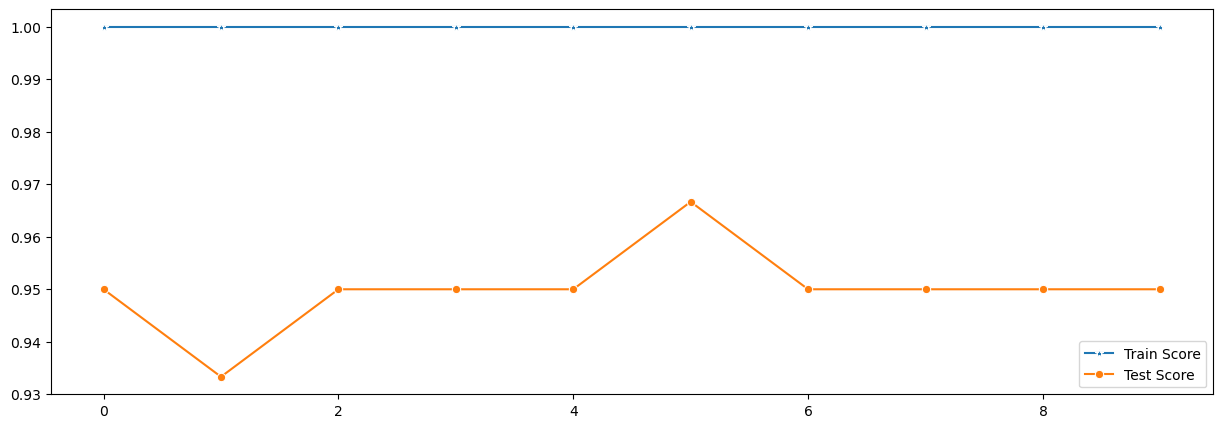

In [220]:
test_score_list = []
train_score_list = []

for i in range(0,10):
    rfc2 = RandomForestClassifier(random_state=i)
    rfc2.fit(x_train, y_train)
    test_score_list.append(rfc2.score(x_test, y_test))
    train_score_list.append(rfc2.score(x_train, y_train))

plt.figure(figsize=(15,5))
p = sns.lineplot(x=range(0,10), y=train_score_list, marker='*', label='Train Score')
p = sns.lineplot(x=range(0,10), y=test_score_list, marker='o', label='Test Score')

➡️ 5가 best

- 최고 성능을 내는 `n_estimators` 찾기

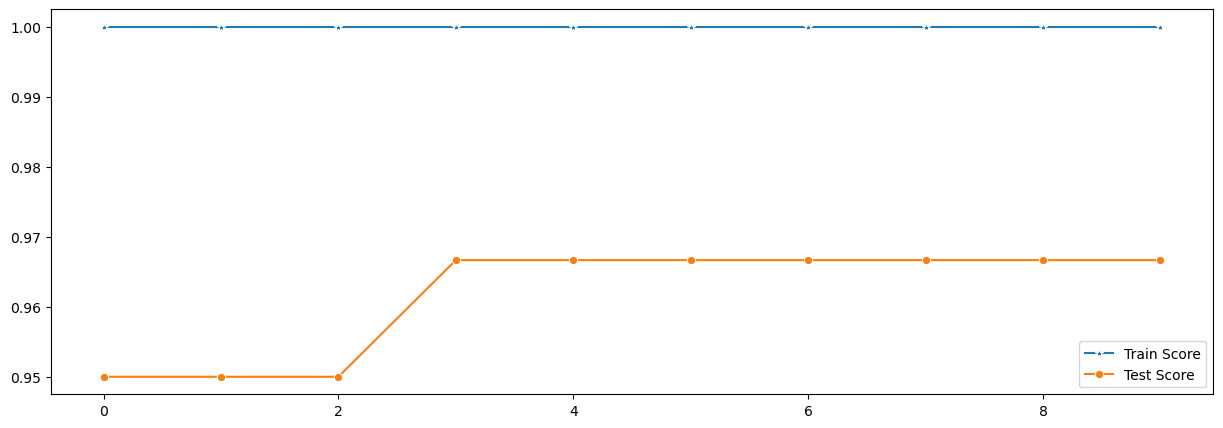

In [227]:
test_score_list = []
train_score_list = []

list_n_estimators = [10,20,30,40,50,60,70,80,90,100]

for i in range(0, len(list_n_estimators)):
    rfc3 = RandomForestClassifier(n_estimators=list_n_estimators[i], random_state=5)
    rfc3.fit(x_train, y_train)
    test_score_list.append(rfc3.score(x_test, y_test))
    train_score_list.append(rfc3.score(x_train, y_train))

plt.figure(figsize=(15,5))
p = sns.lineplot(x=range(0,len(list_n_estimators)), y=train_score_list, marker='*', label='Train Score')
p = sns.lineplot(x=range(0,len(list_n_estimators)), y=test_score_list, marker='o', label='Test Score')

- 찾은 파라미터로 학습

In [233]:
last_rfc = RandomForestClassifier(n_estimators=100, random_state=5)

# Fit
last_rfc.fit(x_train, y_train)

predict = last_rfc.predict(x_test)

print('The accuracy of the Random Forest is',metrics.accuracy_score(y_test, predict))

The accuracy of the Random Forest is 0.9666666666666667


In [235]:
y_pred_en = last_rfc.predict(x_test)

In [241]:
print('Model accuracy score with best parameters:{0:0.4f}'.format(metrics.accuracy_score(y_test,y_pred_en)))

Model accuracy score with best parameters:0.9667


In [245]:
y_pred_train_en = last_rfc.predict(x_train)
y_pred_train_en

array([3, 3, 2, 4, 2, 3, 3, 3, 4, 2, 0, 1, 4, 1, 4, 3, 4, 3, 4, 4, 4, 4,
       3, 4, 2, 4, 1, 3, 2, 3, 4, 2, 0, 0, 3, 3, 1, 3, 3, 4, 4, 4, 4, 3,
       1, 0, 0, 2, 4, 3, 4, 1, 4, 4, 1, 3, 4, 4, 2, 4, 4, 4, 2, 3, 4, 4,
       4, 3, 4, 1, 3, 2, 3, 2, 4, 4, 4, 4, 3, 4, 0, 3, 3, 4, 0, 4, 0, 4,
       4, 0, 4, 4, 2, 3, 4, 3, 2, 4, 1, 4, 4, 3, 4, 4, 4, 4, 4, 4, 1, 4,
       4, 2, 3, 1, 1, 4, 3, 4, 4, 4, 0, 4, 2, 3, 3, 2, 4, 4, 4, 4, 4, 3,
       2, 4, 3, 4, 2, 3, 2, 3])

In [247]:
print('Training-set accuracy score: {0:0.4f}'.format(accuracy_score(y_train, y_pred_train_en)))

Training-set accuracy score: 1.0000


In [249]:
print('Training set score:{:.4f}'.format(last_rfc.score(x_train, y_train)))
print('Test set score:{:.4f}'.format(last_rfc.score(x_test, y_test)))

Training set score:1.0000
Test set score:0.9667


### ✅ Evaluation Classification Models

- 혼동 행렬 사용

In [255]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

cm_des = DecisionTreeClassifier()

# Fit
cm_des.fit(x_train, y_train)

y_pred_cm = cm_des.predict(x_test)
y_true = y_test

cm_des1 = confusion_matrix(y_true, y_pred_cm)
cm_des1

array([[ 4,  0,  2,  0,  0],
       [ 0,  4,  0,  0,  0],
       [ 0,  0,  4,  0,  0],
       [ 0,  0,  0, 19,  0],
       [ 0,  0,  0,  0, 27]], dtype=int64)

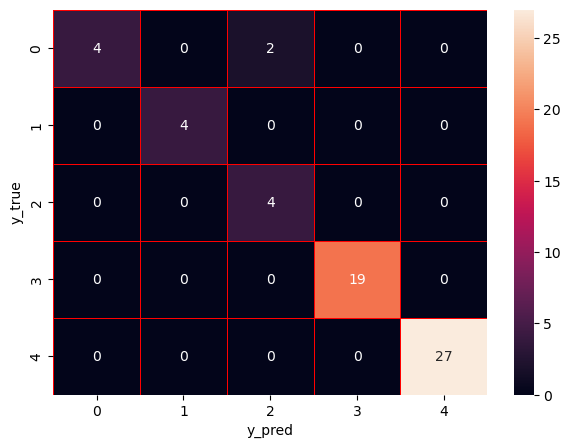

In [257]:
f, ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_des1, annot = True, linewidths=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

- 지니 계수 사용 시

In [263]:
cm_des_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)

# fit
cm_des_gini.fit(x_train, y_train)

y_pred_cm = cm_des_gini.predict(x_test)
y_true = y_test

cm_des2 = confusion_matrix(y_true, y_pred_cm)
cm_des2

array([[ 4,  0,  2,  0,  0],
       [ 0,  0,  0,  4,  0],
       [ 0,  0,  4,  0,  0],
       [ 0,  0,  0, 19,  0],
       [ 0,  0,  0,  0, 27]], dtype=int64)

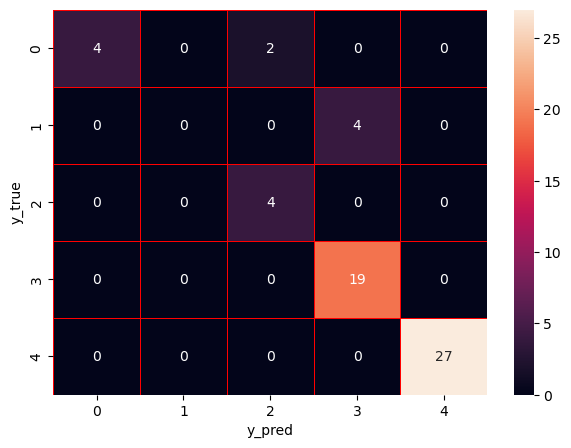

In [265]:
f, ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_des2, annot = True, linewidths=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

- best 파라미터 사용한 랜덤 포레스트

In [271]:
cm_last_rfc = RandomForestClassifier(n_estimators=100, random_state=5)

# fit
cm_last_rfc.fit(x_train, y_train)

y_pred_cm = cm_last_rfc.predict(x_test)
y_true = y_test

cm_rfc = confusion_matrix(y_true, y_pred_cm)
cm_rfc

array([[ 4,  0,  2,  0,  0],
       [ 0,  4,  0,  0,  0],
       [ 0,  0,  4,  0,  0],
       [ 0,  0,  0, 19,  0],
       [ 0,  0,  0,  0, 27]], dtype=int64)

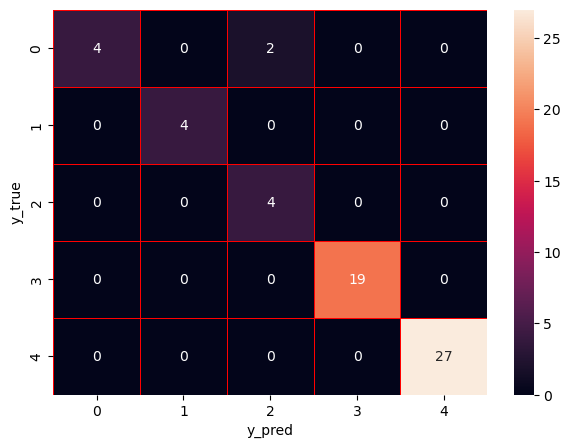

In [273]:
f, ax = plt.subplots(figsize = (7,5))
sns.heatmap(cm_rfc, annot = True, linewidths=0.5, linecolor="red", fmt=".0f", ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

-----

## Kaggle : Beginner Friendly CATBOOST with OPTUNA

### ✅ Data


| 변수명 | 설명 |
|--------|------|
| **Age** | 환자 나이 |
| **Sex** | 환자 성별 <br> - M: 남성<br> - F: 여성 |
| **ChestPainType** | 가슴 통증 유형 <br> - TA: 전형적 협심증<br> - ATA: 비전형적 협심증<br> - NAP: 비협심증성 통증<br> - ASY: 무증상 |
| **RestingBP** | 안정 시 혈압 (mm Hg) |
| **Cholesterol** | 혈청 콜레스테롤 수치 ( mg/dl) |
| **FastingBS** | 공복 혈당 <br> - 1: 공복혈당 > 120 mg/dl<br> - 0: 그렇지 않음 |
| **RestingECG** | 안정 시 심전도 결과 <br> - Normal: 정상<br> - ST: ST-T 파형 이상<br> - LVH: 좌심실 비대 가능성 있음 |
| **MaxHR** | 최대 심박수 (60~202) |
| **ExerciseAngina** | 운동 유발 협심증 여부 <br> - Y: 있음<br> - N: 없음 |
| **Oldpeak** | 운동으로 인한 ST 분절 하강 정도 ( mm) |
| **ST_Slope** | 운동 중 ST 분절 기울기 <br> - Up: 상승<br> - Flat: 평평<br> - Down: 하강 |
| **HeartDisease** | 심장 질환 여부 (타겟 변수) <br> - 1: 있음<br> - 0: 정상 |

### ✅ 데이터 분석

- 라이브러리 import

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.model_selection import KFold,cross_val_score, RepeatedStratifiedKFold,StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import OneHotEncoder,StandardScaler,PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier

import optuna
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import make_column_transformer

from sklearn.model_selection import KFold, cross_val_predict, train_test_split,GridSearchCV,cross_val_score
from sklearn.metrics import accuracy_score,classification_report

#importing plotly and cufflinks in offline mode
import cufflinks as cf
import plotly.offline
cf.go_offline()
cf.set_config_file(offline=False, world_readable=True)


import plotly 
import plotly.express as px
import plotly.graph_objs as go
import plotly.offline as py
from plotly.offline import iplot
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

import missingno as msno

import warnings
warnings.filterwarnings("ignore")

In [13]:
pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows', 900)

pd.set_option('display.max_colwidth',200)

df=pd.read_csv('./heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [17]:
df.duplicated().sum()

0

➡️ 중복 데이터 없음

In [20]:
def missing(df):
    missing_number = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
    missing_values = pd.concat([missing_number, missing_percent], axis=1, keys=['Missing_Number','Missing_Percent'])
    return missing_values

missing(df)

,Missing_Number,Missing_Percent
Age,0,0.0
Sex,0,0.0
ChestPainType,0,0.0
RestingBP,0,0.0
Cholesterol,0,0.0
FastingBS,0,0.0
RestingECG,0,0.0
MaxHR,0,0.0
ExerciseAngina,0,0.0
Oldpeak,0,0.0


➡️ 결측치 없음

In [22]:
numerical = df.drop(['HeartDisease'], axis=1).select_dtypes('number').columns

categorical = df.select_dtypes('object').columns

print(f'Numerical Columns: {df[numerical].columns}')
print('\n')
print(f'Categorical Columns: {df[categorical].columns}')

Numerical Columns: Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'], dtype='object')


Categorical Columns: Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


In [24]:
df[categorical].nunique()

Sex               2
ChestPainType     4
RestingECG        3
ExerciseAngina    2
ST_Slope          3
dtype: int64

- Target Variable

In [27]:
y = df['HeartDisease']
print(f'Percentage of patient had a HeartDisease : {round(y.value_counts(normalize=True)[1]*100, 2)}% --> ({y.value_counts()[1]} patient)\
\nPercentage of patient did not have a HeartDisease: {round(y.value_counts(normalize=True)[0]*100,2)}% --> ({y.value_counts()[0]} patient)')

Percentage of patient had a HeartDisease : 55.34% --> (508 patient)
Percentage of patient did not have a HeartDisease: 44.66% --> (410 patient)


➡️ 약 55%의 환자들이 심장 질환 소유 <br>
➡️ 약 45%의 환자들은 심장 질환 없음

In [87]:
# cufflinks 어떤 방식으로 해봐도 출력이 안떠서 fig 형태로 출력했습니다!

fig = go.Figure(data=[go.Histogram(x=y)])
fig.update_layout(
    title='Heart Disease',
    bargap=0.2
)
fig.show("iframe")

➡️ 살짝 비율이 다르지만 심하지 않음, 평가지표로 정확도 사용 가능

- Numerical Features

In [102]:
df[numerical].describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000


In [92]:
fig = go.Figure()

for col in numerical:
    fig.add_trace(go.Histogram(x=df[col], name=col, opacity=0.5))

fig.update_layout(
    title='Numerical Features',
    barmode='overlay' 
)

fig.show("iframe")

In [102]:
from plotly.subplots import make_subplots

cols = 2
rows = 3

fig = make_subplots(rows=rows, cols=cols, shared_xaxes=False, subplot_titles=numerical)

for i, col in enumerate(numerical):
    row = i // cols + 1
    col_pos = i % cols + 1
    fig.add_trace(
        go.Histogram(x=df[col], nbinsx=50, name=col),
        row=row,
        col=col_pos
    )

fig.show("iframe")

In [165]:
skew_limit = 0.75 #절대값 기준 0.75 이상일 경우 왜곡된 분포로 간주
skew_vals = df[numerical].drop('FastingBS', axis=1).skew()
skew_cols = skew_vals[abs(skew_vals) > skew_limit].sort_values(ascending=False)
skew_cols

Oldpeak    1.022872
dtype: float64

➡️ 대체적으로 정규분포를 따르고 있음 

<Axes: >

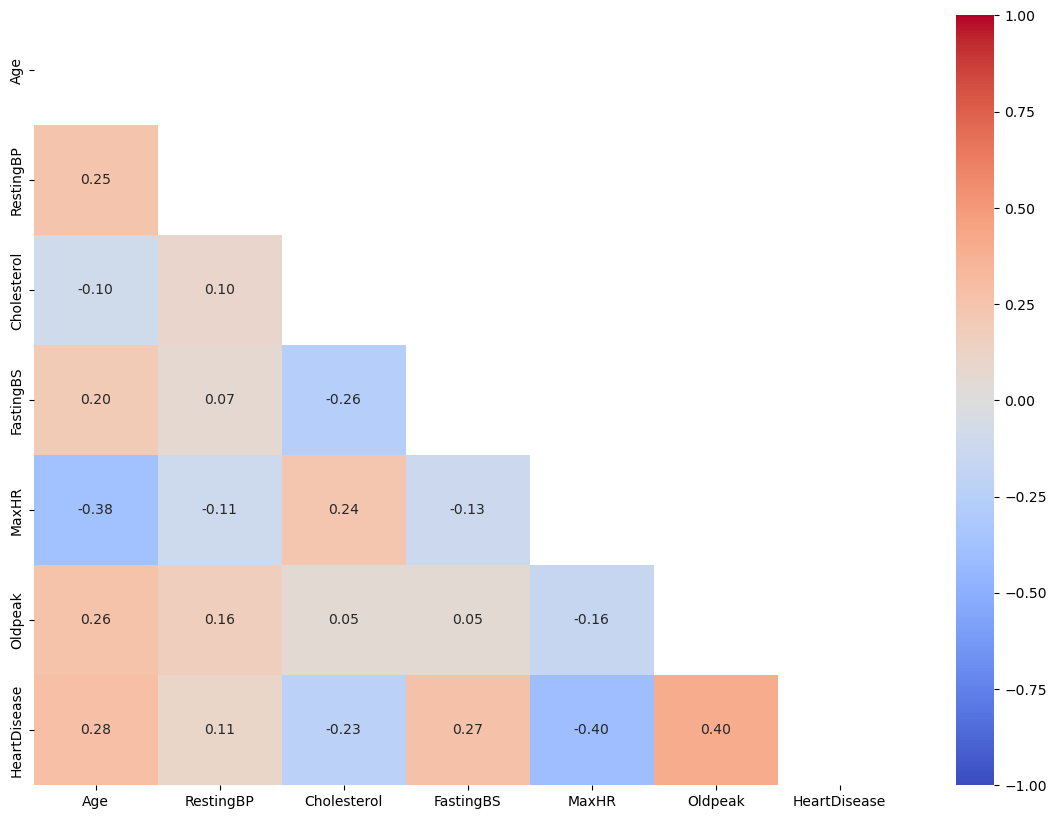

In [169]:
numerical1 = df.select_dtypes('number').columns

matrix = np.triu(df[numerical1].corr())
fig, ax = plt.subplots(figsize = (14,10))
sns.heatmap(df[numerical1].corr(), annot=True, fmt='.2f', vmin=-1, vmax=1, center=0, cmap='coolwarm', mask=matrix, ax=ax)

➡️ target variable과의 약한 상관관계가 존재 

- Categorical Features
  

In [176]:
df[categorical].head()

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
0,M,ATA,Normal,N,Up
1,F,NAP,Normal,N,Flat
2,M,ATA,ST,N,Up
3,F,ASY,Normal,Y,Flat
4,M,NAP,Normal,N,Up


In [182]:
print(f'A female person has a probability of {round(df[df["Sex"]=="F"]["HeartDisease"].mean()*100,2)} % have a HeartDisease')
print()
print(f'A male person has a probability of {round(df[df["Sex"]=="M"]["HeartDisease"].mean()*100,2)} % have a HeartDisease')
print()

A female person has a probability of 25.91 % have a HeartDisease

A male person has a probability of 63.17 % have a HeartDisease



In [190]:
fig = px.histogram(df, x="Sex", color="HeartDisease", width=400, height = 400)
fig.show("iframe")

➡️ 남성이 여성보다 약 2.44배 정도 심장병에 많이 걸려있다.

In [196]:
fig = px.histogram(df, x="ChestPainType", color="HeartDisease", width=400, height=400)
fig.show("iframe")

➡️ 무증상(ASY)인 사람이 비전형적 협심증(ATA) 증상을 가진 사람의 6배 정도 많이 심장병을 가지고 있음 

In [200]:
df.groupby('RestingECG')['HeartDisease'].mean().sort_values(ascending=False)

RestingECG
ST        0.657303
LVH       0.563830
Normal    0.516304
Name: HeartDisease, dtype: float64

In [203]:
fig = px.histogram(df, x="RestingECG", color="HeartDisease", width=400, height=400)
fig.show("iframe")

➡️ 상대적으로 심전도 파형에 이상이 있는 사람(ST)이 더 심장병에 걸린 비율이 높음

In [212]:
df.groupby('ExerciseAngina')['HeartDisease'].mean().sort_values(ascending=False)

ExerciseAngina
Y    0.851752
N    0.351005
Name: HeartDisease, dtype: float64

In [214]:
fig = px.histogram(df, x="ExerciseAngina", color="HeartDisease", width=400, height=400)
fig.show("iframe")

➡️ 운동에의해 유발되는 협심증이 있는 사람(Y)이 2.4배정도 심장병에 더 걸려있음

In [219]:
df.groupby('ST_Slope')['HeartDisease'].mean().sort_values(ascending=False)

ST_Slope
Flat    0.828261
Down    0.777778
Up      0.197468
Name: HeartDisease, dtype: float64

In [221]:
fig = px.histogram(df, x="ST_Slope", color="HeartDisease", width=400, height=400)
fig.show("iframe")

➡️ 심전도의 ST구간(심실이 수축한 후 이완되기 전까지)의 기울기가 up인 사람이 명확히 심장병에 덜 걸림

### ✅ 정리


타겟 변수는 거의 균형 잡힌 분포를 보임


수치형 변수들은 타겟 변수(심장병 유무)와의 상관관계가 약함

- Oldpeak는 심장병과 양의 상관관계를 보임  
- 최대 심박수(Maximum heart rate)와 콜레스테롤 수치(Cholesterol)는 심장병과 음의 상관관계를 보임  

- 성별에 따른 차이를 보면, 남성이 여성보다 약 2.44배 더 심장병을 가질 가능성이 높음
- ASY(무증상성 가슴 통증) 증상을 가진 사람은 ATA(비정형 협심증)을 가진 사람보다 심장병에 걸릴 확률이 약 6배 더 높다.
- ST-T 파형 이상(ST-T wave abnormality)을 가진 사람은 다른 사람보다 심장병에 걸릴 가능성이 더 높다.
- 운동 유발 협심증(Exercise-induced angina)의 경우, "Yes"라고 응답한 사람이 심장병에 걸릴 가능성이 약 2.4배 더 높음
- ST_Slope(최대 운동 중 ST 분절 기울기)는, Up을 가진 사람은 나머지 두 유형보다 심장병에 걸릴 가능성이 낮다.

In [32]:
accuracy = []
model_names = []

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ohe = OneHotEncoder()
ct = make_column_transformer((ohe, categorical), remainder='passthrough')

model = DummyClassifier(strategy = 'constant', constant=1)
pipe = make_pipeline(ct, model)
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
accuracy.append(round(accuracy_score(y_test, y_pred),4))
print(f'model : {model} and accuracy score is : {round(accuracy_score(y_test, y_pred),4)}')

model_names = ['DummyClassifier']
dummy_result_df = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
dummy_result_df

model : DummyClassifier(constant=1, strategy='constant') and accuracy score is : 0.5942


,Accuracy
DummyClassifier,0.5942


➡️ 항상 'HeartDisease = 1'이라고 예측하는 dummy 모델 정확도를 계산해 비교 기준으로 삼기 

- logistic / linear discriminant / SVC / KNN

In [36]:
accuracy = []
model_names = []

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ohe = OneHotEncoder()
ct = make_column_transformer((ohe, categorical), remainder='passthrough')

lr = LogisticRegression(solver='liblinear')
lda= LinearDiscriminantAnalysis()
svm = SVC(gamma='scale')
knn = KNeighborsClassifier()

models = [lr,lda,svm,knn]

for model in models: 
    pipe = make_pipeline(ct, model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    accuracy.append(round(accuracy_score(y_test, y_pred),4))
    print (f'model : {model} and  accuracy score is : {round(accuracy_score(y_test, y_pred),4)}')

model_names = ['Logistic','LinearDiscriminant','SVM','KNeighbors']
result_df1 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df1

model : LogisticRegression(solver='liblinear') and  accuracy score is : 0.8841
model : LinearDiscriminantAnalysis() and  accuracy score is : 0.8696
model : SVC() and  accuracy score is : 0.7246
model : KNeighborsClassifier() and  accuracy score is : 0.7174


,Accuracy
Logistic,0.8841
LinearDiscriminant,0.8696
SVM,0.7246
KNeighbors,0.7174


➡️ 전처리와 모델을 파이프라인으로 묶어 학습 > 예측 > 정확도 평가<br>
➡️ 각 모델의 정확도를 accuracy 리스트에 저장하고 출력

In [39]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ohe= OneHotEncoder()
s= StandardScaler()
ct1= make_column_transformer((ohe,categorical),(s,numerical))  


lr = LogisticRegression(solver='liblinear')
lda= LinearDiscriminantAnalysis()
svm = SVC(gamma='scale')
knn = KNeighborsClassifier()

models = [lr,lda,svm,knn]

for model in models: 
    pipe = make_pipeline(ct1, model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    accuracy.append(round(accuracy_score(y_test, y_pred),4))
    print (f'model : {model} and  accuracy score is : {round(accuracy_score(y_test, y_pred),4)}')

model_names = ['Logistic_scl','LinearDiscriminant_scl','SVM_scl','KNeighbors_scl']
result_df2 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df2

model : LogisticRegression(solver='liblinear') and  accuracy score is : 0.8804
model : LinearDiscriminantAnalysis() and  accuracy score is : 0.8696
model : SVC() and  accuracy score is : 0.8841
model : KNeighborsClassifier() and  accuracy score is : 0.8841


,Accuracy
Logistic_scl,0.8804
LinearDiscriminant_scl,0.8696
SVM_scl,0.8841
KNeighbors_scl,0.8841


➡️ 수치형 변수는 표준화(StandardScaler) 처리<br>
➡️ KNN, SVM이 표준화를 통해 성능이 향상됨 

- Ensemble Models

In [44]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ohe= OneHotEncoder()
ct= make_column_transformer((ohe,categorical),remainder='passthrough')  

ada = AdaBoostClassifier(random_state=0)
gb = GradientBoostingClassifier(random_state=0)
rf = RandomForestClassifier(random_state=0)
et=  ExtraTreesClassifier(random_state=0)

models = [ada,gb,rf,et]

for model in models: 
    pipe = make_pipeline(ct, model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    accuracy.append(round(accuracy_score(y_test, y_pred),4))
    print (f'model : {model} and  accuracy score is : {round(accuracy_score(y_test, y_pred),4)}')

model_names = ['Ada','Gradient','Random','ExtraTree']
result_df3 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df3

model : AdaBoostClassifier(random_state=0) and  accuracy score is : 0.8659
model : GradientBoostingClassifier(random_state=0) and  accuracy score is : 0.8768
model : RandomForestClassifier(random_state=0) and  accuracy score is : 0.8877
model : ExtraTreesClassifier(random_state=0) and  accuracy score is : 0.8804


,Accuracy
Ada,0.8659
Gradient,0.8768
Random,0.8877
ExtraTree,0.8804


➡️ 앙상블 모델(AdaBoost, Gradient Boosting, RandomForest, Extra Trees)을 이용하여 HeartDisease 예측 정확도를 비교<br>
➡️ 4가지 앙상블 모델 모두 비슷한 성능을 보임 

- Famous trio (XGBoost & LigthGBM & Catboost)

In [51]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ohe= OneHotEncoder()
ct= make_column_transformer((ohe,categorical),remainder='passthrough')  

xgbc = XGBClassifier(random_state=0)
lgbmc=LGBMClassifier(random_state=0)


models = [xgbc,lgbmc]

for model in models: 
    pipe = make_pipeline(ct, model)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    accuracy.append(round(accuracy_score(y_test, y_pred),4))

model_names = ['XGBoost','LightGBM']
result_df4 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df4

[LightGBM] [Info] Number of positive: 344, number of negative: 298
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 354
[LightGBM] [Info] Number of data points in the train set: 642, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.535826 -> initscore=0.143548
[LightGBM] [Info] Start training from score 0.143548
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

,Accuracy
XGBoost,0.8478
LightGBM,0.8732


➡️ catBoost는 더 잘할 수 있다.


- 🐱 CatBoost : Open-source ML liBrary<BR>
  Yandex에서 개발한 Gradient Boosting 기반의 머신러닝 알고리즘, 특히 범주형 데이터 처리에 강한 성능을 보임

In [58]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
categorical_features_indices = np.where(X.dtypes != np.float64)[0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = CatBoostClassifier(verbose=False,random_state=0)

model.fit(X_train, y_train,cat_features=categorical_features_indices,eval_set=(X_test, y_test))
y_pred = model.predict(X_test)
accuracy.append(round(accuracy_score(y_test, y_pred),4))

model_names = ['Catboost_default']
result_df5 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df5

,Accuracy
Catboost_default,0.8804


➡️ 시간이 약간 더 오래 걸렸다

- Optuna를 사용한 catboost 하이퍼 파라미터 튜닝

In [63]:
# CatBoost + Optuna를 이용한 하이퍼파라미터 튜닝 함수 정의

def objective(trial):
    X= df.drop('HeartDisease', axis=1)
    y= df['HeartDisease']
    categorical_features_indices = np.where(X.dtypes != np.float64)[0]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Optuna가 실험할 하이퍼파라미터 후보들 
    param = {
        "objective": trial.suggest_categorical("objective", ["Logloss", "CrossEntropy"]),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.01, 0.1),
        "depth": trial.suggest_int("depth", 1, 12),
        "boosting_type": trial.suggest_categorical("boosting_type", ["Ordered", "Plain"]),
        "bootstrap_type": trial.suggest_categorical(
            "bootstrap_type", ["Bayesian", "Bernoulli", "MVS"]
        ),
        "used_ram_limit": "3gb",
    }

    # bootstrap_type에 따른 추가 하이퍼파라미터 설정
    if param["bootstrap_type"] == "Bayesian":
        param["bagging_temperature"] = trial.suggest_float("bagging_temperature", 0, 10)
    elif param["bootstrap_type"] == "Bernoulli":
        param["subsample"] = trial.suggest_float("subsample", 0.1, 1)

    # CatBoost 분류기 객체 (Optuna로 제안된 파라미터)
    cat_cls = CatBoostClassifier(**param)

    cat_cls.fit(X_train, y_train, eval_set=[(X_test, y_test)], cat_features=categorical_features_indices,verbose=0, early_stopping_rounds=100)

    # 예측 및 정확도 계산
    preds = cat_cls.predict(X_test)
    pred_labels = np.rint(preds)
    accuracy = accuracy_score(y_test, pred_labels)
    return accuracy



if __name__ == "__main__":
    # 정확도 기준으로 최적화
    study = optuna.create_study(direction="maximize")
    # objective 함수 기준 50번 시도하거나 600초 동안 탐색
    study.optimize(objective, n_trials=50, timeout=600)

    print("Number of finished trials: {}".format(len(study.trials)))

    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))

    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))

[I 2025-04-06 13:26:07,646] A new study created in memory with name: no-name-bb13da6c-14ef-4fe0-9efa-d162ae23211d
[I 2025-04-06 13:26:30,091] Trial 0 finished with value: 0.894927536231884 and parameters: {'objective': 'Logloss', 'colsample_bylevel': 0.09025836387425454, 'depth': 9, 'boosting_type': 'Plain', 'bootstrap_type': 'MVS'}. Best is trial 0 with value: 0.894927536231884.
[I 2025-04-06 13:26:37,803] Trial 1 finished with value: 0.8985507246376812 and parameters: {'objective': 'CrossEntropy', 'colsample_bylevel': 0.03321714662960758, 'depth': 7, 'boosting_type': 'Plain', 'bootstrap_type': 'Bayesian', 'bagging_temperature': 7.833178848225982}. Best is trial 1 with value: 0.8985507246376812.
[I 2025-04-06 13:26:50,351] Trial 2 finished with value: 0.8876811594202898 and parameters: {'objective': 'CrossEntropy', 'colsample_bylevel': 0.046860543696315086, 'depth': 12, 'boosting_type': 'Plain', 'bootstrap_type': 'Bernoulli', 'subsample': 0.1510207115874564}. Best is trial 1 with valu

Number of finished trials: 44
Best trial:
  Value: 0.9021739130434783
  Params: 
    objective: CrossEntropy
    colsample_bylevel: 0.06358441342514845
    depth: 12
    boosting_type: Plain
    bootstrap_type: Bernoulli
    subsample: 0.9924934998548031


**😺 Catboost 파라미터**
- Objective: 과적합 감지와 최적 모델 선택을 위한 평가 지표
- colsample_bylevel:  학습 속도를 높여주며, 일반적으로 모델 성능(정확도 등)에 큰 영향을 주지 않음
- depth: 트리의 최대 깊이
- boosting_type: 기본적으로 작은 데이터셋에 적합한 방식으로 설정됨<br>
   과적합을 방지하는 데 효과적이지만, 계산 비용이 많이 든다.<br>
   학습 속도를 빠르게 하고 싶다면 튜닝해보기 
- bootstrap_type: 기본적으로 객체(데이터 포인트)의 가중치를 샘플링하는 방식은 Bayesian으로 설정, bootstrap_type을 설정하고 샘플 비율(subsample)을 1보다 작게 지정하면 학습 속도가 더 빨라질 수 있다.

- best 파라미터로 다시 재학습

In [74]:
accuracy =[]
model_names =[]


X= df.drop('HeartDisease', axis=1)
y= df['HeartDisease']
categorical_features_indices = np.where(X.dtypes != np.float64)[0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = CatBoostClassifier(verbose=False,random_state=0,
                           objective= 'CrossEntropy',
                           colsample_bylevel= 0.06358441342514845,
                           depth= 12,
                           boosting_type= 'Plain',
                           bootstrap_type= 'Bernoulli',
                           subsample= 0.9924934998548031)
          
model.fit(X_train, y_train,cat_features=categorical_features_indices,eval_set=(X_test, y_test))
y_pred = model.predict(X_test)
accuracy.append(round(accuracy_score(y_test, y_pred),4))
print(classification_report(y_test, y_pred))

model_names = ['Catboost_tuned']
result_df6 = pd.DataFrame({'Accuracy':accuracy}, index=model_names)
result_df6

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       112
           1       0.93      0.91      0.92       164

    accuracy                           0.90       276
   macro avg       0.90      0.90      0.90       276
weighted avg       0.90      0.90      0.90       276



,Accuracy
Catboost_tuned,0.9022


➡️ 0.8804에서 0.9022로 정확도가 향상됨 

- 피처 중요도 출력

In [77]:
feature_importance = np.array(model.get_feature_importance())
features = np.array(X_train.columns)
fi={'features':features,'feature_importance':feature_importance}
df_fi = pd.DataFrame(fi)
df_fi.sort_values(by=['feature_importance'], ascending=True,inplace=True)

fig = px.bar(df_fi, x='feature_importance', y='features',title="CatBoost Feature Importance",height=500)
fig.show("iframe")

- 모델 비교 시각화

In [79]:
result_final = pd.concat([dummy_result_df,result_df1,result_df2,result_df3,result_df4,result_df5,result_df6],axis=0)

In [81]:
result_final.sort_values(by=['Accuracy'], ascending=True,inplace=True)
fig = px.bar(result_final, x='Accuracy', y=result_final.index,title='Model Comparison',height=600,labels={'index':'MODELS'})
fig.show("iframe")